# COK UK 2025 — Monte Carlo Tournament Simulation

Simulation of a **194 player / 6 round** Swiss-style tournament, modeled on the **Clash of Kings UK 2025**.

ELO distribution: real player ELOs from the [European KoW ELO ranking](https://www.kingsofwarmasters.fr/elo), cross-referenced with the [COK UK 2025 participant list](https://kowmasters.com/index.php?p=event&i=426). Players without a published ELO are assigned a medium-to-low value.

In [1]:
N_PLAYERS = 194
MIN_ELO = 928
MAX_ELO = 1573
AVG_ELO = 1250
NUM_ROUNDS = 6

## COK UK 2025 ELO Distribution\n\nWe cross-reference the 194 participants of the Clash of Kings UK 2025 with the European ELO database (302 published ratings, range 928–1573).\n\nPlayers without a published ELO are assigned a random value from a uniform distribution in the 1050–1180 range (medium-to-low level).

In [2]:
import numpy as np
from numpy import random

# EU ELO database (302 published ratings from kingsofwarmasters.fr, April 2026)
eu_elo = {
    "Tom Robinson": 1573, "Chris Lynch": 1565, "Jonathon Quayle": 1532,
    "Antonio Carrasco Perez": 1516, "Piotr Nowak": 1496, "Timothée Aubriot": 1492,
    "Radoslaw Brylowski": 1484, "Arthur Vaisse": 1481, "Simon Brand": 1477,
    "Nico Félix": 1466, "Vincent Miller": 1464, "Steve Tonneau": 1458,
    "Piotr Darkowski": 1453, "Justin Gisby-Clark": 1441, "Daniel King": 1436,
    "Damien BM": 1422, "Javier Talavero": 1417, "Ian Sturgess": 1416,
    "Richard Tomlinson": 1407, "Peter Wrench": 1406, "Paco Lopez": 1406,
    "Richard Laking": 1405, "Chris Christopherson": 1405, "Nacho Albillo": 1400,
    "Javier Ancizu Vergara": 1400, "Antoine Granet": 1399, "Michael Smith": 1396,
    "Kacper Szczytowski": 1396, "Joanna Mitchell": 1393, "Quentin Le Doussal": 1391,
    "Maxime Sadon": 1390, "Jean Werkling": 1388, "Antonio Fernandez Longino": 1387,
    "Mario Murillo Raja": 1386, "Jorge Cuerva Morante": 1377, "Matt Gorham": 1363,
    "Vincent Sintes": 1360, "Theo den Boer": 1360, "Patrick C. Kloiber": 1359,
    "Barry Joyner": 1355, "Alban De Ubeda": 1352, "Ed Herzig": 1352,
    "Duncan Shabb": 1351, "Richard Luke": 1347, "Simon Heaney": 1343,
    "Simon Cooper": 1339, "Paul Burke": 1337, "Julien Debord": 1335,
    "Jake Boyd-Gill": 1335, "Matthew Hobday": 1335, "Bruno Gavazzi": 1332,
    "Exequiel Ferreyra": 1332, "Glen Wareing": 1331, "Francesco Madiai": 1329,
    "Ben Hampshire": 1325, "Mike Yeung": 1325, "ddr": 1324,
    "Mario Pinós Quejido": 1323, "Andy Marshall": 1323, "Maximilian Mayo-Dell": 1323,
    "Céleste Desbrus": 1320, "Joshua McHale": 1319, "Florence Anna Maunders": 1316,
    "Carlos Muñoz": 1314, "Steve Hildrew": 1313, "Elliot Morrish": 1312,
    "Andrea Fulloni": 1312, "Jorge Moreno Diaz": 1311, "Michel Blanc": 1309,
    "Olivier Coquel": 1308, "Alberto Galan": 1308, "Aaron Rankin": 1307,
    "Robert Phipps": 1306, "Jake Wilstrop": 1305, "Martin D.": 1304,
    "Maciej Reda": 1302, "Daniel Graves": 1301, "Christian Wolf": 1300,
    "Marco Giudici": 1299, "Samuel Minette": 1298, "Heath Barnes": 1298,
    "Eric Leleu": 1297, "Alex Lesec": 1295, "Kenny Bintz": 1295,
    "Stephanie Berry": 1293, "James Sykes": 1293, "Paul Fox": 1293,
    "Thibault Roux": 1291, "Carlos De la Flor": 1291, "Brendan Heath": 1291,
    "Estiben": 1289, "Paul Lider": 1289, "Andrew Hawley": 1289,
    "Rachid Velle": 1288, "Konrad Krzanowski": 1288, "Christopher Dwane": 1288,
    "Pablo Triguero LLopes": 1287, "Vidar H.": 1286, "Martin Ofner": 1286,
    "Giorgio Isabella": 1285, "Simon Tanner": 1285, "George Kirke": 1285,
    "Riccardo Pepi": 1284, "Marcin Gòrczak": 1283, "Oscar Runa": 1283,
    "Daniel Bailey": 1281, "Daniel Wolfgang Wright": 1279, "Nick Davies": 1278,
    "Łukasz Jarochowski": 1277, "Martin Dinsley": 1276, "Alan Pratt": 1274,
    "Vincent Den Boer": 1273, "Mathis Félix": 1271, "Stephan Baldauf": 1271,
    "Shane Heaney": 1270, "David Fletcher": 1266, "Vincent Bernat": 1265,
    "Pierre-Antoine Leroux": 1265, "Markus Schafrath": 1264, "Ignacio Sanchez Lopez": 1264,
    "Matt Goody": 1263, "Andrea Madiai": 1263, "Kévin Chanard": 1262,
    "Jon Gunns": 1261, "Kolm Florian": 1260, "Thierry Pluchard": 1260,
    "Paweł Ryśnik": 1260, "Alistair Oliver Vowles": 1257, "Bernhard Küttner": 1256,
    "Tom King": 1255, "Robert Sims": 1255, "Maxime Gerbier": 1254,
    "Gerard Courtney": 1254, "Jerry Marshall": 1253, "Dietmar Eisinger": 1251,
    "Diego Jiménez Cabañas": 1249, "Darek Darkowski": 1248, "Edward Barnett": 1246,
    "Steven Pearce": 1244, "Andy Ransome": 1243, "Cailean Dunbar": 1242,
    "James Dunbar": 1239, "Fraser Scott": 1238, "Leo Midwinter": 1236,
    "Kevin Hureaux": 1235, "Maciej Rasiński": 1234, "Morphée The Joker": 1232,
    "Clément Caron": 1232, "James Williams": 1230, "Raúl Hilara Parra": 1229,
    "Bruno Sroczynski": 1228, "Ian Rodger": 1228, "Ben Fell": 1228,
    "Øyvind T.": 1227, "Zilvinas Aleksa": 1224, "Robert Hutson": 1224,
    "Llagho Motorolo": 1223, "Rodolphe Police": 1222, "Jose Maria": 1221,
    "Tom Wiggins": 1220, "Nicola Pagano": 1219, "Jake Salmonsmith": 1219,
    "Michael Yeung": 1218, "Chris Smith": 1218, "Alvaro Lareo": 1217,
    "Jorge Blanco": 1215, "Maciej Szczytowski": 1214, "Julien Ledan": 1212,
    "Jose Carlos Huerta Calvo": 1212, "Janice Stother": 1211,
    "Jérémie Drapier": 1204, "Matthias Leitner": 1204, "Jez Gurney": 1202,
    "Miguel Angel Santiago": 1201, "Paul Welsh": 1200, "Richard Miles": 1199,
    "Peter Swift": 1199, "Mark Dell": 1199, "David Walker": 1198,
    "Derek Bartlett": 1198, "Ivan Rodríguez": 1196, "Grant Alexander": 1195,
    "Mathieu Lesueur": 1194, "Daniel Read": 1192, "Nicola Carrara": 1191,
    "Sam Sowden": 1190, "Aran Golden": 1190, "Daniel Garnett": 1189,
    "Eric Hornoy": 1188, "Mark Cunningham": 1185, "Kevin Haney": 1185,
    "Claudio Cappelletti": 1185, "Matthew Rose": 1184, "Steven Pearson": 1184,
    "Daniel Gonzalez Arrastio": 1182, "Sergio Morales Gonzalez": 1182,
    "Ian Whipp": 1182, "Patrick Baradeau": 1181, "Christopher Fucci": 1180,
    "Andy Smith": 1179, "Alexandre Motte": 1177, "Tim Hewitt": 1176,
    "James Douglas": 1175, "Mathieu Cholet": 1174, "Peter Jackson": 1173,
    "Ashley Clare": 1171, "Pascual Ruiz Fernández": 1171, "Ed Stevenson": 1169,
    "Chris Walsh": 1167, "Adrien Pourtier": 1167, "Steve Evans": 1167,
    "Jonathan Luke": 1166, "Stephen Stead": 1166, "Laurent Bos": 1165,
    "Warren Stevens": 1164, "Andrew Walker": 1163, "Peter": 1163,
    "David Musgrave": 1163, "Kevin Garrigan": 1162, "Richard Heath": 1161,
    "Todd Durkin": 1159, "Maxime Boucher": 1158, "David Ledrich": 1155,
    "Carl Smith": 1155, "Mick McKee": 1153, "Richard Jackson": 1148,
    "Samuel Ceranos": 1147, "Bartosz Zawadzki": 1145, "Jessica Townshend": 1145,
    "Frantic Gamer": 1144, "Matt Thompson": 1143, "Martin Binns": 1143,
    "Stéphane Decramer": 1140, "Julian Booth": 1139, "Matthew Green": 1135,
    "Ian Whittaker": 1133, "Chris Thomas": 1131, "Alexander McWilliam": 1131,
    "James Mintram": 1131, "Ismael Vicente Alonso": 1130, "Eledan": 1129,
    "Constantin Mannweiler": 1129, "Liam Dvorak": 1127, "Francisco Losada": 1125,
    "Christian": 1125, "Martin Collins": 1125, "Chris Pudney": 1118,
    "Stephen Bell": 1114, "Rusty Shackleford": 1112, "Gavin Downey": 1111,
    "Gabriel Küttner": 1108, "Simon Mason-Partridge": 1107, "Bob Aspland": 1107,
    "David Wildey": 1105, "Juancho Bernabeu": 1103, "Walter Dirix": 1102,
    "Jean Luc Gildore": 1101, "Neil Scott": 1100, "Ian McDermott": 1096,
    "Dan Brown": 1094, "David Bell": 1093, "James Police Meurville": 1091,
    "Matthew Godin": 1091, "James Cockburn": 1090, "Darren Ware": 1090,
    "Drew Smith": 1089, "Liam Leitner": 1086, "Benjamin Haage": 1084,
    "Wesley Ryan": 1083, "Greg Joynson": 1081, "Ashley Thornton": 1080,
    "Dominique Mouly": 1079, "Daniel Haslam": 1078, "Fred Oslo": 1077,
    "Kurt": 1077, "Borja Justicia León": 1077, "Wolfgang Kuwaldt": 1072,
    "Marcus Midwinter": 1070, "Laurent Mardivirin": 1069, "Simon Robinson": 1064,
    "Mark Mee": 1063, "Guilhem Lauzeral": 1060, "Mike Longman": 1059,
    "Shane Evans-Pask": 1056, "Russell Harris": 1056, "Elias Bossert": 1050,
    "Joris Lattrey": 1049, "Kevin Turpe": 1046, "Dave Kitcat": 1043,
    "John Randall": 1036, "Louis Wheatley": 1034, "Christopher Parslow": 1032,
    "Sylvain Aicardo": 1030, "Juan Jose Soriano Rodriguez": 1025,
    "Raul Oya Abajo": 1021, "Nigel Emsen": 1018, "Kenzo Minette": 1003,
    "Seb Reeves": 998, "Amador Pastor": 994, "Tony Ringrose": 958,
    "Heather Armstead": 952, "Alex Barton": 928,
}

# COK UK 2025 participants (194 players) — name mapping to EU ELO keys
# Some names differ between kowmasters.com and kingsofwarmasters.fr
cok_name_to_elo_key = {
    "Tom Robinson": "Tom Robinson",
    "Javier Talavero": "Javier Talavero",
    "Piotr Darkowski": "Piotr Darkowski",
    "Piotr Nowak": "Piotr Nowak",
    "Jorge Cuerva": "Jorge Cuerva Morante",
    "John Quayle": "Jonathon Quayle",
    "Justin Gisby-Clark": "Justin Gisby-Clark",
    "Timothee Aubriot": "Timothée Aubriot",
    "Lukasz Jarochowski": "Łukasz Jarochowski",
    "Kacper Szczytowski": "Kacper Szczytowski",
    "Mario Murillo": "Mario Murillo Raja",
    "Richard Tomlinson": "Richard Tomlinson",
    "Joshua McHale": "Joshua McHale",
    "Francesco": "Francesco Madiai",
    "Chris Christopherson": "Chris Christopherson",
    "Pete Wrench": "Peter Wrench",
    "Brendan Heath": "Brendan Heath",
    "Alex Chaves": None,  # US player, no EU ELO
    "Ulysse Naessens": None,  # unpublished
    "Leo Midwinter": "Leo Midwinter",
    "Simon Cooper": "Simon Cooper",
    "Dan King": "Daniel King",
    "Steve Tonneau": "Steve Tonneau",
    "Nicolas Felix": "Nico Félix",
    "Ian Sturgess": "Ian Sturgess",
    "Chris Lynch": "Chris Lynch",
    "Daniel Bailey": "Daniel Bailey",
    "Florence Maunders": "Florence Anna Maunders",
    "Antonio Fernandez": "Antonio Fernandez Longino",
    "Paul Lider": "Paul Lider",
    "James Kor": None,  # AS player, no EU ELO
    "Ray Shields": None,  # CA player, no EU ELO
    "Konrad Krzanowski": "Konrad Krzanowski",
    "Paco lopez Portillo": "Paco Lopez",
    "Radoslaw Brylowski": "Radoslaw Brylowski",
    "Joanna Mitchell": "Joanna Mitchell",
    "Richard Laking": "Richard Laking",
    "Simon Brand": "Simon Brand",
    "Fraser Scott": "Fraser Scott",
    "Elliot Morrish": "Elliot Morrish",
    "Steven Pearson": "Steven Pearson",
    "Martin Dahl": "Martin D.",
    "George Kirke": "George Kirke",
    "Mick McKee": "Mick McKee",
    "Kim Holter": None,  # NO player, unpublished
    "Michael Smith": "Michael Smith",
    "Shane Heaney": "Shane Heaney",
    "Martin Ofner": "Martin Ofner",
    "Matt Gee": None,  # no exact match in published ELO
    "Page Neo": None,  # AS player, no EU ELO
    "Jake Salmonsmith": "Jake Salmonsmith",
    "Ben Fell": "Ben Fell",
    "Alan Pratt": "Alan Pratt",
    "Ed Barnett": "Edward Barnett",
    "Richard Luke": "Richard Luke",
    "Maciej Reda": "Maciej Reda",
    "Christopher Dwane": "Christopher Dwane",
    "Antonio Carrasco": "Antonio Carrasco Perez",
    "Darren Ware": "Darren Ware",
    "Derek Bartlett": "Derek Bartlett",
    "Jonathan Luke": "Jonathan Luke",
    "Marco Giudici": "Marco Giudici",
    "Mario Pinos": "Mario Pinós Quejido",
    "Alistair Vowles": "Alistair Oliver Vowles",
    "Tom King": "Tom King",
    "Nacho Albillo": "Nacho Albillo",
    "Alberto Galan": "Alberto Galan",
    "Carl Smith": "Carl Smith",
    "Ignacio Sanchez": "Ignacio Sanchez Lopez",
    "Matt Hobday": "Matthew Hobday",
    "Simon Heaney": "Simon Heaney",
    "Barry Joyner": "Barry Joyner",
    "Glen Wareing": "Glen Wareing",
    "Andrea Madiai": "Andrea Madiai",
    "Matt Goody": "Matt Goody",
    "Nick Williams": None,  # in unpublished list
    "Aaron Rankin": "Aaron Rankin",
    "Tim Hewitt": "Tim Hewitt",
    "Peter Jackson": "Peter Jackson",
    "Max Mayo-Dell": "Maximilian Mayo-Dell",
    "Matthias Leitner": "Matthias Leitner",
    "Oscar Runa": "Oscar Runa",
    "Marcelo Rouco": None,  # US player
    "Chris Smith": "Chris Smith",
    "Rafael Urquieta Ahumada": None,  # in unpublished list
    "Simon Tanner": "Simon Tanner",
    "Daniel Wolfgang Wright": "Daniel Wolfgang Wright",
    "Walter Simpson": None,  # in unpublished list
    "Tom Wiggins": "Tom Wiggins",
    "Henning Lundheim": None,  # NO player, unpublished
    "Martin Collins": "Martin Collins",
    "Sam Sowden": "Sam Sowden",
    "Vidar Hemmingby": "Vidar H.",
    "Miguel Angel Santiago": "Miguel Angel Santiago",
    "Darek Darkowski": "Darek Darkowski",
    "Jared Law Gee Hwan": None,  # AS player
    "Dave Walker": "David Walker",
    "Andy Ransome": "Andy Ransome",
    "Nigel Emsen": "Nigel Emsen",
    "Michael Yeung": "Michael Yeung",
    "Ged Courtney": "Gerard Courtney",
    "Leszek Dzienkowski": None,  # PL, unpublished
    "Jeff Horton": None,  # not in database
    "Nathan Cerone": None,  # CA player
    "Richard Heath": "Richard Heath",
    "Rad Bien": None,  # in unpublished list
    "Stephan Baldauf": "Stephan Baldauf",
    "Bruno Gavazzi": "Bruno Gavazzi",
    "David Wildey": "David Wildey",
    "Mark Zielinski": None,  # in unpublished list
    "Andy Marshall": "Andy Marshall",
    "Rafal Bien": None,  # in unpublished list
    "Robert Phipps": "Robert Phipps",
    "Kevin Haney": "Kevin Haney",
    "James Dunbar": "James Dunbar",
    "Kurt Kunz": "Kurt",
    "Peter Swift": "Peter Swift",
    "Aran Golden": "Aran Golden",
    "Ed Stevenson": "Ed Stevenson",
    "Paul Welsh": "Paul Welsh",
    "Cailean Dunbar": "Cailean Dunbar",
    "Raul Hilara": "Raúl Hilara Parra",
    "Darryl Fleming": None,  # in unpublished list
    "Martin Binns": "Martin Binns",
    "Danny Flash Graves": "Daniel Graves",
    "Mathis Felix": "Mathis Félix",
    "Paul Fox": "Paul Fox",
    "Jordan Bollin": None,  # US player
    "James Mintram": "James Mintram",
    "Chris Walsh": "Chris Walsh",
    "Drew Smith": "Drew Smith",
    "Pascual Ruiz": "Pascual Ruiz Fernández",
    "Jon Gunns": "Jon Gunns",
    "Oyvind Thomassen": "Øyvind T.",
    "Richard Miles": "Richard Miles",
    "Kevin Garrigan": "Kevin Garrigan",
    "Constantin Mannweiler": "Constantin Mannweiler",
    "Mark Mee": "Mark Mee",
    "Kolm Florian": "Kolm Florian",
    "Jez Gurney": "Jez Gurney",
    "Andrew Walker": "Andrew Walker",
    "Chris Thomas": "Chris Thomas",
    "Stian West": None,  # NO, unpublished
    "Fred Oslo": "Fred Oslo",
    "Mark Dell": "Mark Dell",
    "Daniel Haslam": "Daniel Haslam",
    "James Moore": None,  # in unpublished list
    "Daniel Garnett": "Daniel Garnett",
    "Rune Gronheden Prosgaard": None,  # NO, unpublished
    "Steve Piper": None,  # in unpublished list
    "Mike Longman": "Mike Longman",
    "Norman quigg": None,  # in unpublished list
    "Alex Barton": "Alex Barton",
    "Martyn Young": None,  # in unpublished list
    "Richard Jackson": "Richard Jackson",
    "Chris Eames": None,  # in unpublished list
    "Robert Hutson": "Robert Hutson",
    "Michael Nursey": None,  # in unpublished list
    "Neil Scott": "Neil Scott",
    "Tom Freeman": None,  # in unpublished list
    "Steve Evans": "Steve Evans",
    "Raul Oya": "Raul Oya Abajo",
    "Gavin Downey": "Gavin Downey",
    "Simon Parfitt": None,  # in unpublished list
    "Chris Pudney": "Chris Pudney",
    "Simon Robinson": "Simon Robinson",
    "Wesley Ryan": "Wesley Ryan",
    "Andrew Bruce-Sach": None,  # DE, unpublished
    "Sam Jones": None,  # in unpublished list
    "liam leitner": "Liam Leitner",
    "Matthew Godin": "Matthew Godin",
    "Daniel Hayden": None,  # in unpublished list
    "Matt Thompson": "Matt Thompson",
    "Stephen Bell": "Stephen Bell",
    "Sam Stones": None,  # in unpublished list
    "Alexander Krysta": None,  # not in database
    "John Randall": "John Randall",
    "Simon Mason-Partridge": "Simon Mason-Partridge",
    "Dave Kitcat": "Dave Kitcat",
    "Shane Evans-Pask": "Shane Evans-Pask",
    "Robert Butler": None,  # in unpublished list
    "christopher parslow": "Christopher Parslow",
    "Johan Groenstad": None,  # NO, unpublished
    "Alexander McWilliam": "Alexander McWilliam",
    "Russell Harris": "Russell Harris",
    "Tony Ringrose": "Tony Ringrose",
    "John Brough": None,  # in unpublished list
    "Andrew Cole": None,  # not in database
    "Martin Dunbar": None,  # in unpublished list
    "Gerald Kelly": None,  # not in database
    "Heather Armstead": "Heather Armstead",
    "Adam Young": None,  # in unpublished list
    "Warren Stevens": "Warren Stevens",
    "Jake Ciarapica": None,  # not in database
}

# Build the 194 ELO values
cok_elos = []
matched = 0
unmatched_names = []
for cok_name, elo_key in cok_name_to_elo_key.items():
    if elo_key is not None and elo_key in eu_elo:
        cok_elos.append(eu_elo[elo_key])
        matched += 1
    else:
        # Assign medium-to-low ELO for unranked players
        cok_elos.append(int(random.uniform(1050, 1180)))
        unmatched_names.append(cok_name)

cok_elos = np.array(cok_elos, dtype=float)
print(f"Total players: {len(cok_elos)}")
print(f"Matched with EU ELO: {matched}")
print(f"Assigned estimated ELO: {len(unmatched_names)}")
print(f"ELO range: {cok_elos.min():.0f} - {cok_elos.max():.0f}")
print(f"Mean ELO: {cok_elos.mean():.0f}, Median: {np.median(cok_elos):.0f}")
print(f"\nUnmatched: {unmatched_names}")

Total players: 194
Matched with EU ELO: 150
Assigned estimated ELO: 44
ELO range: 928 - 1573
Mean ELO: 1215, Median: 1194

Unmatched: ['Alex Chaves', 'Ulysse Naessens', 'James Kor', 'Ray Shields', 'Kim Holter', 'Matt Gee', 'Page Neo', 'Nick Williams', 'Marcelo Rouco', 'Rafael Urquieta Ahumada', 'Walter Simpson', 'Henning Lundheim', 'Jared Law Gee Hwan', 'Leszek Dzienkowski', 'Jeff Horton', 'Nathan Cerone', 'Rad Bien', 'Mark Zielinski', 'Rafal Bien', 'Darryl Fleming', 'Jordan Bollin', 'Stian West', 'James Moore', 'Rune Gronheden Prosgaard', 'Steve Piper', 'Norman quigg', 'Martyn Young', 'Chris Eames', 'Michael Nursey', 'Tom Freeman', 'Simon Parfitt', 'Andrew Bruce-Sach', 'Sam Jones', 'Daniel Hayden', 'Sam Stones', 'Alexander Krysta', 'Robert Butler', 'Johan Groenstad', 'John Brough', 'Andrew Cole', 'Martin Dunbar', 'Gerald Kelly', 'Adam Young', 'Jake Ciarapica']


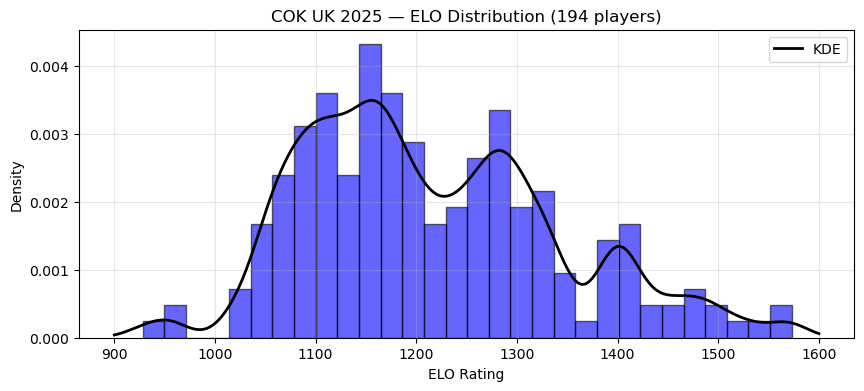

Sample mean: 1213, std: 133


In [3]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Plot the COK ELO distribution
plt.figure(figsize=(10, 4))
plt.hist(cok_elos, bins=30, density=True, alpha=0.6, color='b', edgecolor='black')
kde = gaussian_kde(cok_elos, bw_method=0.15)
x = np.linspace(900, 1600, 200)
plt.plot(x, kde(x), 'k', linewidth=2, label='KDE')
plt.title('COK UK 2025 — ELO Distribution (194 players)')
plt.xlabel('ELO Rating')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

def generate_cok_elo_ratings(num_ratings=N_PLAYERS):
    """Sample ELO ratings from the COK distribution via KDE."""
    samples = kde.resample(num_ratings).flatten()
    samples = np.clip(samples, MIN_ELO, MAX_ELO)
    return samples

# Test
test_sample = generate_cok_elo_ratings(1000)
print(f"Sample mean: {test_sample.mean():.0f}, std: {test_sample.std():.0f}")

## Match Model\n\nSame ELO-based match model as the other notebooks: ELO → win probability → polynomial-fitted W/D/L probabilities → biased draw for score margins.

In [4]:
import scipy.stats as stats
from scipy.stats import truncnorm

def win_probability(rating_a, rating_b):
    prob_a = 1 / (1 + 10 ** ((rating_b - rating_a) / 400))
    return prob_a

Es = [(float(i) * 0.1) for i in range(11)]
def interpolate(data):
    coeffs = np.polyfit(Es, data, 4)
    poly_func = np.poly1d(coeffs)
    return poly_func

win_data  = [0., 0.09, 0.17, 0.24, 0.31, 0.40, 0.51, 0.64, 0.77, 0.89, 1.0]
draw_data = [0., 0.02, 0.06, 0.12, 0.18, 0.20, 0.18, 0.12, 0.06, 0.02, 0.0]
loss_data = win_data[:]; loss_data.reverse()
p_win  = interpolate(win_data)
p_draw = interpolate(draw_data)
p_loss = interpolate(loss_data)

def biased_draw(mean, std_dev=0.1):
    while True:
        x = random.normal(mean, std_dev)
        if 0.0 <= x <= 1.0:
            return x

def play_match(rating_a, rating_b):
    """Determine match outcome between players A and B.
    Returns [outcome, rate_a, rate_b] where outcome: 1=loss, 2=draw, 3=win for A."""
    prob_a = win_probability(rating_a, rating_b)
    roll = random.uniform(0, 1)
    if roll <= p_loss(prob_a):
        outcome_number = 1
    elif roll <= p_loss(prob_a) + p_draw(prob_a):
        outcome_number = 2
    else:
        outcome_number = 3
    outcome_rate_a = biased_draw(p_win(prob_a))
    outcome_rate_b = biased_draw(p_win(1. - prob_a))
    return [outcome_number, outcome_rate_a, outcome_rate_b]

def rev(num):
    if num == 1:
        return 3
    elif num == 3:
        return 1
    return 2

print("Match model ready.")

Match model ready.


## Player class and scoring systems

In [5]:
class Player:
    def __init__(self, idx, elo):
        self.idx = idx
        self.elo = elo
        self.score = 0
        self.resulttrack = []
        self.opponenttrack = []
        self.track = []
    def __str__(self):
        return f"Player {self.idx}: Elo={self.elo}, Score={self.score}\n\t, Track{self.track}"
    def __repr__(self):
        return f"Player {self.idx}: Elo={self.elo}, Score={self.score}\n\t, Track{self.track}"

def naive_score(result_triplet, round_number):
    res1 = result_triplet[0]
    res2 = rev(res1) 
    return [10*res1 + result_triplet[1], 10*res2 + result_triplet[2]]

from math import ceil, floor

NK_scores= [
    [1,7,0,3,0,3],
    [2,6,0,2,0,2],
    [1,6,0,3,0,4],
    [1,7,0,6,0,5],
    [1,7,0,6,0,5],
    [1,7,0,6,0,5],
]

def result_sp_win(player_score,round_number):    
    return ceil(float(NK_scores[round_number][0] + (NK_scores[round_number][1] - NK_scores[round_number][0]) * player_score))

def result_sp_loss(player_score,round_number, winner_sp):
    return min(winner_sp-1,floor(float(NK_scores[round_number][4] + (NK_scores[round_number][5] - NK_scores[round_number][4]) * player_score)))

def result_draw_win(player_score,round_number):
    return ceil(float(NK_scores[round_number][2] + (NK_scores[round_number][3] - NK_scores[round_number][2]) * player_score))

def result_draw_loss(player_score,round_number, winner_sp):
    return winner_sp

def final_score(res, sp_score, normalised_score):
    return res *5 + min(5,sp_score) + floor(float(normalised_score * 5)) 

def nk_score(result_triplet, round_number):
    res1 = result_triplet[0]
    res2 = rev(res1) 
    if(res1 == 3):
        normalised_score_win  = result_triplet[1]
        normalised_score_loss = result_triplet[2]
        sp_win   = result_sp_win (normalised_score_win, round_number)
        sp_loss  = result_sp_loss(normalised_score_loss,round_number, sp_win)
        return [final_score(res1, sp_win, normalised_score_win), final_score(res2, sp_loss, normalised_score_loss)] 
    if (res1 == 2):
        if(result_triplet[1]>result_triplet[2]):
            normalised_score_win  = result_triplet[1]
            normalised_score_loss = result_triplet[2]
            sp_win   = result_draw_win (normalised_score_win, round_number)
            sp_loss  = result_draw_loss(normalised_score_loss,round_number, sp_win)
            return [final_score(res1, sp_win, normalised_score_win), final_score(res2, sp_loss, normalised_score_loss)] 
        else:
            normalised_score_win  = result_triplet[2]
            normalised_score_loss = result_triplet[1]
            sp_win   = result_draw_win (normalised_score_win, round_number)
            sp_loss  = result_draw_loss(normalised_score_loss,round_number, sp_win)
            return [final_score(res1, sp_loss, normalised_score_loss), final_score(res2, sp_win, normalised_score_win)] 
    else:
        normalised_score_win  = result_triplet[2]
        normalised_score_loss = result_triplet[1]
        sp_win   = result_sp_win (normalised_score_win, round_number)
        sp_loss  = result_sp_loss(normalised_score_loss,round_number, sp_win)
        return [final_score(res1, sp_loss, normalised_score_loss), final_score(res2, sp_win, normalised_score_win)]

def result_sp_win_BJ(player1_score,player2_score):
    score1 = max(0, np.round((player1_score - player2_score) * 4))
    return score1, -score1

def result_sp_loss_BJ(player1_score,player2_score):
    score2, score1 = result_sp_win(player2_score, player1_score)
    return score1, score2

def result_sp_draw_BJ(player1_score,player2_score):
    return 0,0

def result_kp_BJ(player1_score,player2_score):
    score1 = np.round((player1_score- player2_score) * 3)
    return score1, -score1

def bj_score(result_triplet, round_number):
    res1 = result_triplet[0]
    res2 = rev(res1) 
    if(res1 == 3):
        normalised_score_win  = result_triplet[1]
        normalised_score_loss = result_triplet[2]
        score1_sp, score2_sp = result_sp_win_BJ(normalised_score_win,normalised_score_loss)
        score1_kp, score2_kp = result_kp_BJ    (normalised_score_win,normalised_score_loss)        
        return [14+score1_sp+score1_kp, 7+score2_sp+score2_kp] 
    if(res1==1):        
        normalised_score_win  = result_triplet[2]
        normalised_score_loss = result_triplet[1]
        score2_sp, score1_sp = result_sp_win_BJ(normalised_score_win,normalised_score_loss)
        score2_kp, score1_kp = result_kp_BJ    (normalised_score_win,normalised_score_loss)        
        return [14+score1_sp+score1_kp, 7+score2_sp+score2_kp] 
    else:
        score1_kp, score2_kp = result_kp_BJ(result_triplet[1],result_triplet[2])    
        return [10+score1_kp, 10+score2_kp]

print("Player class and scoring functions ready.")

Player class and scoring functions ready.


## Metrics

Same 9 metrics as the other notebooks: elo distance, wins, bigger the better, submariners, games balance, replays, eat the weak, strength of schedule, winner accuracy, top 3 accuracy.

In [6]:
from scipy.stats import kendalltau
from collections import defaultdict

def elodistance(tournament_ranking, top_n=None):
    ranking = tournament_ranking[:top_n] if top_n else tournament_ranking
    elos = [player.elo for player in ranking]
    sortedelos = sorted(elos, reverse=True)
    tau, p_value = kendalltau(sortedelos, elos)
    return (1 - tau) / 2

def num_win(player):
    wins = sum(1 for r in player.resulttrack if r == 3)
    return wins

def num_draw(player):
    draws = sum(1 for r in player.resulttrack if r == 2)
    return draws

def num_win_draw(player):
    wins = num_win(player)
    draws = num_draw(player)
    return 100* wins + 10 *draws

def winner_has_win(tournament_ranking):
    wins = [num_win_draw(player) for player in tournament_ranking]
    sortedwins = sorted(wins, reverse=True)
    tau, p_value = kendalltau(wins, sortedwins)
    return (1 - tau) / 2

def bigger_the_better(tournament_ranking):
    win_groups = defaultdict(list)
    for rank_pos, player in enumerate(tournament_ranking):
        wins = num_win_draw(player)
        win_groups[wins].append((rank_pos, player))
    total_pairs = 0
    discordant = 0
    for wins, players in win_groups.items():
        if len(players) < 2:
            continue
        for i in range(len(players)):
            for j in range(i + 1, len(players)):
                rank_i, player_i = players[i]
                rank_j, player_j = players[j]
                total_pairs += 1
                if (rank_i < rank_j) != (player_i.elo > player_j.elo):
                    discordant += 1
    return discordant / total_pairs if total_pairs > 0 else 0

def submariner_metric(tournament_ranking):
    # Build a reference ranking: wins desc, draws desc, late-loss score desc
    # Late-loss score = sum of round indices where player lost (higher = lost later = better)
    scores = []
    for player in tournament_ranking:
        wins = sum(1 for r in player.resulttrack if r == 3)
        draws = sum(1 for r in player.resulttrack if r == 2)
        loss_round_sum = sum(r for r, res in enumerate(player.resulttrack) if res == 1)
        score = wins * 10000 + draws * 100 + loss_round_sum
        scores.append(score)
    sorted_scores = sorted(scores, reverse=True)
    tau, _ = kendalltau(sorted_scores, scores)
    return (1 - tau) / 2

def games_balance(tournament_ranking):
    elo_map = {p.idx: p.elo for p in tournament_ranking}
    all_elos = list(elo_map.values())
    max_gap = max(all_elos) - min(all_elos)
    if max_gap == 0:
        return 0
    total_gap = 0
    total_games = 0
    for player in tournament_ranking:
        for opp_idx in player.opponenttrack[1:]:
            total_gap += abs(player.elo - elo_map[opp_idx])
            total_games += 1
    return (total_gap / total_games) / max_gap if total_games > 0 else 0

def replays_metric(tournament_ranking):
    total_replays = 0
    total_games = 0
    for player in tournament_ranking:
        seen = set()
        for opp_idx in player.opponenttrack:
            total_games += 1
            if opp_idx in seen:
                total_replays += 1
            seen.add(opp_idx)
    return total_replays / total_games if total_games > 0 else 0

def eat_the_weak(tournament_ranking):
    elo_map = {p.idx: p.elo for p in tournament_ranking}
    win_groups = defaultdict(list)
    for rank_pos, player in enumerate(tournament_ranking):
        wins = num_win_draw(player)
        avg_opp_elo = sum(elo_map[o] for o in player.opponenttrack) / len(player.opponenttrack) if player.opponenttrack else 0
        win_groups[wins].append((rank_pos, avg_opp_elo))
    total_pairs = 0
    weak_advantage = 0
    for wins, players in win_groups.items():
        if len(players) < 2:
            continue
        for i in range(len(players)):
            for j in range(i + 1, len(players)):
                rank_i, avg_opp_i = players[i]
                rank_j, avg_opp_j = players[j]
                if avg_opp_i == avg_opp_j:
                    continue
                total_pairs += 1
                if (rank_i < rank_j) == (avg_opp_i < avg_opp_j):
                    weak_advantage += 1
    return weak_advantage / total_pairs if total_pairs > 0 else 0

def compute_sos(player, players_by_idx):
    """Buchholz score: sum of (wins*15 + draws*10) of all opponents faced so far."""
    return sum(num_win_draw(players_by_idx[opp_idx]) for opp_idx in player.opponenttrack)

def sos_metric(tournament_ranking):
    players_by_idx = {p.idx: p for p in tournament_ranking}
    wd_groups = defaultdict(list)
    for rank_pos, player in enumerate(tournament_ranking):
        wins = num_win(player)
        draws = num_draw(player)
        sos = compute_sos(player, players_by_idx)
        wd_groups[(wins, draws)].append((rank_pos, sos))
    total_pairs = 0
    discordant = 0
    for wd, players in wd_groups.items():
        if len(players) < 2:
            continue
        for i in range(len(players)):
            for j in range(i + 1, len(players)):
                rank_i, sos_i = players[i]
                rank_j, sos_j = players[j]
                if sos_i == sos_j:
                    continue
                total_pairs += 1
                if (rank_i < rank_j) != (sos_i > sos_j):
                    discordant += 1
    return discordant / total_pairs if total_pairs > 0 else 0

def winner_accuracy(tournament_ranking):
    best_elo = max(p.elo for p in tournament_ranking)
    return 0 if tournament_ranking[0].elo == best_elo else 1

def top_3_accuracy(tournament_ranking):
    """Cost = 1 - (overlap of true top-3 ELO with ranking top-3) / 3.
    0 = all three correct, 1 = none correct."""
    sorted_by_elo = sorted(tournament_ranking, key=lambda p: -p.elo)
    true_top3_idx = {p.idx for p in sorted_by_elo[:3]}
    ranked_top3_idx = {p.idx for p in tournament_ranking[:3]}
    overlap = len(true_top3_idx & ranked_top3_idx)
    return 1 - overlap / 3

print("All metrics ready.")

All metrics ready.


## Tournament engine (on-the-fly matching)

Key difference from the other notebooks: instead of precomputing all possible match outcomes, we call `play_match()` on the fly during each round. This is much more efficient for 194 players (97 matches/round × 6 rounds = 582 match simulations vs 18,721 precomputed pairs).

In [7]:
import copy

# ── Weight configurations ──────────────────────────────────────────
WEIGHT_CONFIGS = {
    "early":     [6, 5, 4, 3, 2, 1],
    "skip_r1":   [0, 5, 4, 3, 2, 1],
    "flat_r1":   [1, 5, 4, 3, 2, 1],
    "late":      [1, 2, 3, 4, 5, 6],
    "flat":      [1, 1, 1, 1, 1, 1],
    "skip_late": [0, 2, 3, 4, 5, 6],
}

def make_weighted_fn(weights):
    def fn(player):
        score = 0
        for r, res in enumerate(player.resulttrack):
            w = weights[r] if r < len(weights) else 0
            if res == 3:
                score += w
            elif res == 2:
                score += w * 0.5
        return score
    return fn

WEIGHTED_FNS = {name: make_weighted_fn(w) for name, w in WEIGHT_CONFIGS.items()}

def compute_sos_r2(player, players_by_idx):
    return sum(num_win_draw(players_by_idx[opp_idx]) for opp_idx in player.opponenttrack[1:])

def streak_bonus(player):
    streak = 0
    for res in player.resulttrack:
        if res == 3:
            streak += 1
        else:
            break
    return max(0, streak - 1)

def streak_metric(player):
    return num_win_draw(player) + streak_bonus(player)

def round_weighted_wins(player):
    return WEIGHTED_FNS["early"](player)

def num_wins(player):
    return sum(1 for r in player.resulttrack if r == 3)

def num_draws(player):
    return sum(1 for r in player.resulttrack if r == 2)

def sort_players(current_ranking, ranking_mode):
    if ranking_mode.startswith("wt_"):
        suffix = ranking_mode[3:]
        use_sos = suffix.endswith("_sos")
        config_name = suffix[:-4] if use_sos else suffix
        wfn = WEIGHTED_FNS[config_name]
        if use_sos:
            players_by_idx = {p.idx: p for p in current_ranking}
            return sorted(current_ranking, key=lambda p: (
                -num_wins(p), -num_draws(p), -wfn(p), -compute_sos(p, players_by_idx), -p.score))
        else:
            return sorted(current_ranking, key=lambda p: (
                -num_wins(p), -num_draws(p), -wfn(p), -p.score))
    elif ranking_mode == "streak":
        return sorted(current_ranking, key=lambda p: (-num_wins(p), -num_draws(p), -streak_metric(p)))
    elif ranking_mode == "streak_sos":
        players_by_idx = {p.idx: p for p in current_ranking}
        return sorted(current_ranking, key=lambda p: (-num_wins(p), -num_draws(p), -streak_bonus(p), -compute_sos(p, players_by_idx)))
    elif ranking_mode == "streak_sos_r2":
        players_by_idx = {p.idx: p for p in current_ranking}
        return sorted(current_ranking, key=lambda p: (-num_wins(p), -num_draws(p), -streak_bonus(p), -compute_sos_r2(p, players_by_idx)))
    elif ranking_mode == "weighted":
        return sorted(current_ranking, key=lambda p: (-num_wins(p), -num_draws(p), -round_weighted_wins(p)))
    elif ranking_mode == "weighted_sos":
        players_by_idx = {p.idx: p for p in current_ranking}
        return sorted(current_ranking, key=lambda p: (-num_wins(p), -num_draws(p), -round_weighted_wins(p), -compute_sos(p, players_by_idx)))
    elif ranking_mode == "naive":
        return sorted(current_ranking, key=lambda p: (-num_wins(p), -num_draws(p), -p.score))
    elif ranking_mode == "wdl_sos":
        players_by_idx = {p.idx: p for p in current_ranking}
        return sorted(current_ranking, key=lambda p: (-num_wins(p), -num_draws(p), -compute_sos(p, players_by_idx)))
    else:  # "score"
        return sorted(current_ranking, key=lambda p: -p.score)

def play_tournament(player_elos, score_function, ranking_mode="score", final_ranking_mode=None):
    """Play a Swiss tournament with on-the-fly match generation."""
    if final_ranking_mode is None:
        final_ranking_mode = ranking_mode
    players = [Player(i, elo) for (i, elo) in enumerate(player_elos)]
    current_ranking = list(players)
    def play_round(current_round):
        nonlocal current_ranking
        if current_round == NUM_ROUNDS:
            current_ranking = sort_players(current_ranking, final_ranking_mode)
            return current_ranking
        round_outcomes = [play_match(current_ranking[i].elo, current_ranking[i+1].elo)
                          for i in range(0, len(current_ranking), 2)]
        scores = [score_function(outcome, current_round) for outcome in round_outcomes]
        for i, score in enumerate(scores):
            current_ranking[2*i].score += score[0]
            current_ranking[2*i+1].score += score[1]
            current_ranking[2*i].resulttrack.append(round_outcomes[i][0])
            current_ranking[2*i+1].resulttrack.append(rev(round_outcomes[i][0]))
            current_ranking[2*i].opponenttrack.append(current_ranking[2*i+1].idx)
            current_ranking[2*i+1].opponenttrack.append(current_ranking[2*i].idx)
        current_ranking = sort_players(current_ranking, ranking_mode)
        return play_round(current_round+1)
    return play_round(0), []

def play_pool_tournament(player_elos, score_function, ranking_mode="score", final_ranking_mode=None):
    """3 rounds of pool play (groups of 4, full round-robin) then 2 Swiss rounds."""
    if final_ranking_mode is None:
        final_ranking_mode = ranking_mode
    n = len(player_elos)
    players = [Player(i, elo) for i, elo in enumerate(player_elos)]
    # Shuffle and split into pools of 4
    indices = list(range(n))
    random.shuffle(indices)
    pools = [indices[i:i+4] for i in range(0, n, 4)]
    # Round-robin pairings for a 4-player group (3 rounds)
    rr_pairings = [[(0, 1), (2, 3)], [(0, 2), (1, 3)], [(0, 3), (1, 2)]]
    for rnd, pairs in enumerate(rr_pairings):
        for pool in pools:
            for a_local, b_local in pairs:
                pa = players[pool[a_local]]
                pb = players[pool[b_local]]
                outcome = play_match(pa.elo, pb.elo)
                sc = score_function(outcome, rnd)
                pa.score += sc[0]
                pb.score += sc[1]
                pa.resulttrack.append(outcome[0])
                pb.resulttrack.append(rev(outcome[0]))
                pa.opponenttrack.append(pb.idx)
                pb.opponenttrack.append(pa.idx)
    # Global ranking after pool phase
    current_ranking = sort_players(list(players), ranking_mode)
    # Swiss phase: 2 more rounds (round indices 3 and 4)
    for rnd in range(3, 5):
        round_outcomes = [play_match(current_ranking[i].elo, current_ranking[i+1].elo)
                          for i in range(0, len(current_ranking), 2)]
        scores_list = [score_function(outcome, rnd) for outcome in round_outcomes]
        for i, sc in enumerate(scores_list):
            current_ranking[2*i].score += sc[0]
            current_ranking[2*i+1].score += sc[1]
            current_ranking[2*i].resulttrack.append(round_outcomes[i][0])
            current_ranking[2*i+1].resulttrack.append(rev(round_outcomes[i][0]))
            current_ranking[2*i].opponenttrack.append(current_ranking[2*i+1].idx)
            current_ranking[2*i+1].opponenttrack.append(current_ranking[2*i].idx)
        current_ranking = sort_players(current_ranking, ranking_mode)
    current_ranking = sort_players(current_ranking, final_ranking_mode)
    return current_ranking, []

print("Tournament engine ready (Swiss + Pool).")

Tournament engine ready (Swiss + Pool).


## Run analysis — 194 players, 6 rounds, 500 tournaments

In [8]:
import multiprocessing
import os

N_WORKERS = min(4, max(1, os.cpu_count() - 2))

# scoring_systems: [name, score_fn, pairing_mode, final_ranking_mode, format]
scoring_systems = [
    ["BJ",          bj_score,    "score",       None,      "swiss"],
    ["NK",          nk_score,    "score",       None,      "swiss"],
    ["W.flat+SOS",  naive_score, "wt_flat_sos", None,      "swiss"],
    ["NK|WDL+SOS",  nk_score,    "score",       "wdl_sos", "swiss"],
    ["BJ|WDL+SOS",  bj_score,    "score",       "wdl_sos", "swiss"],
    ["Pool+NK",         nk_score, "score",       None,      "pool"],
    ["Pool+NK|WDL+SOS", nk_score, "score",       "wdl_sos", "pool"],
    ["Pool+BJ",         bj_score, "score",       None,      "pool"],
    ["Pool+W.flat+SOS", naive_score, "wt_flat_sos", None,     "pool"],
]

N_SIM_PLAYERS = 200  # divisible by 4 for pools, even for Swiss

metrics = [
    ["elo distance", elodistance],
    ["elo distance top 10", lambda r: elodistance(r, top_n=10)],
    ["wins", winner_has_win],
    ["bigger the better", bigger_the_better],
    ["submariners", submariner_metric],
    ["games balance", games_balance],
    ["eat the weak", eat_the_weak],
    ["strength of schedule", sos_metric],
    ["winner accuracy", winner_accuracy],
    ["top 3 accuracy", top_3_accuracy],
]

def _run_chunk_cok(n_tournaments):
    """Process n_tournaments with on-the-fly ELO generation. Returns {metric: {system: [values]}}."""
    partial = {}
    for t in range(n_tournaments):
        elos = generate_cok_elo_ratings(N_SIM_PLAYERS)
        for ss_entry in scoring_systems:
            ss_name, ss, mode, final_mode, fmt = ss_entry
            if fmt == "pool":
                final_rank, _ = play_pool_tournament(elos, ss, ranking_mode=mode, final_ranking_mode=final_mode)
            else:
                final_rank, _ = play_tournament(elos, ss, ranking_mode=mode, final_ranking_mode=final_mode)
            for [metric_name, metric_fn] in metrics:
                if metric_name not in partial:
                    partial[metric_name] = {}
                if ss_name not in partial[metric_name]:
                    partial[metric_name][ss_name] = []
                partial[metric_name][ss_name].append(metric_fn(final_rank))
    return partial

def _init_worker():
    """Seed each worker's RNG from OS entropy."""
    np.random.seed(None)

def run_analysis(n_tournaments=500):
    # Distribute tournaments across workers
    base = n_tournaments // N_WORKERS
    remainder = n_tournaments % N_WORKERS
    chunks = [base + (1 if i < remainder else 0) for i in range(N_WORKERS)]

    print(f"Running {n_tournaments} tournaments on {N_WORKERS} workers...")
    with multiprocessing.Pool(N_WORKERS, initializer=_init_worker) as pool:
        results = pool.map(_run_chunk_cok, chunks)

    # Merge partial results
    analysis = {}
    for partial in results:
        for metric_name, systems in partial.items():
            if metric_name not in analysis:
                analysis[metric_name] = {}
            for ss_name, values in systems.items():
                if ss_name not in analysis[metric_name]:
                    analysis[metric_name][ss_name] = []
                analysis[metric_name][ss_name].extend(values)

    # Aggregate
    for [metric_name, _] in metrics:
        for ss_entry in scoring_systems:
            ss_name = ss_entry[0]
            raw_data = analysis[metric_name][ss_name]
            analysis[metric_name][ss_name] = {
                'average cost': sum(raw_data) / len(raw_data),
                'worst': max(raw_data),
                'standard deviation': np.std(raw_data, ddof=1)
            }
    print("Done!")
    return analysis

print("Analysis functions ready.")


Analysis functions ready.


In [9]:
import pandas as pd

def display_results(res):
    rows = []
    for metric_name, systems in res.items():
        for sys_name, stats in systems.items():
            rows.append({
                'Criterion': metric_name,
                'System': sys_name,
                'Avg Cost': stats['average cost'],
            })
    df = pd.DataFrame(rows)
    df = df.pivot_table(index='Criterion', columns='System', values='Avg Cost', aggfunc='first')

    vmax = df.values.max()

    def gradient(row):
        styles = []
        for v in row.values:
            t = max(0.0, min(1.0, v / vmax)) if vmax > 0 else 0
            r = int(34 + t * (204 - 34))
            g = int(170 - t * (170 - 51))
            b = int(34 + t * (51 - 34))
            styles.append(f'background-color: rgb({r},{g},{b}); color: white; font-weight: bold')
        return styles

    return (df.style
              .apply(gradient, axis=1)
              .format('{:.2f}')
              .set_properties(**{'font-size': '14px'}))

print("Display function ready.")

Display function ready.


In [10]:
%%time
res = run_analysis(n_tournaments=500)


Running 500 tournaments on 4 workers...


Done!
CPU times: user 54.2 ms, sys: 89.2 ms, total: 143 ms
Wall time: 1min 50s


In [11]:
display_results(res)

System,BJ,BJ|WDL+SOS,NK,NK|WDL+SOS,Pool+BJ,Pool+NK,Pool+NK|WDL+SOS,Pool+W.flat+SOS,W.flat+SOS
Criterion,,,,,,,,,
bigger the better,0.26,0.35,0.17,0.36,0.31,0.19,0.39,0.43,0.42
eat the weak,0.30,0.29,0.39,0.32,0.41,0.50,0.41,0.37,0.29
elo distance,0.23,0.32,0.23,0.30,0.26,0.23,0.29,0.30,0.30
elo distance top 10,0.36,0.44,0.38,0.39,0.39,0.43,0.43,0.41,0.41
games balance,0.17,0.17,0.16,0.17,0.21,0.19,0.19,0.20,0.18
strength of schedule,0.36,0.00,0.39,0.00,0.38,0.40,0.00,0.00,0.00
submariners,0.36,0.03,0.12,0.02,0.34,0.10,0.03,0.02,0.02
top 3 accuracy,0.68,0.84,0.68,0.81,0.75,0.74,0.83,0.84,0.81
winner accuracy,0.78,0.88,0.75,0.85,0.84,0.77,0.89,0.91,0.89


In [12]:
# Print results - compact
for metric_name, systems in res.items():
    line = f"{metric_name:25s} |"
    for sys_name, stats in systems.items():
        line += f" {sys_name}={stats['average cost']:.3f} |"
    print(line)

elo distance              | BJ=0.232 | NK=0.230 | W.flat+SOS=0.297 | NK|WDL+SOS=0.302 | BJ|WDL+SOS=0.319 | Pool+NK=0.228 | Pool+NK|WDL+SOS=0.294 | Pool+BJ=0.263 | Pool+W.flat+SOS=0.299 |
elo distance top 10       | BJ=0.363 | NK=0.380 | W.flat+SOS=0.414 | NK|WDL+SOS=0.391 | BJ|WDL+SOS=0.436 | Pool+NK=0.432 | Pool+NK|WDL+SOS=0.427 | Pool+BJ=0.385 | Pool+W.flat+SOS=0.413 |
wins                      | BJ=0.353 | NK=0.091 | W.flat+SOS=0.000 | NK|WDL+SOS=0.000 | BJ|WDL+SOS=0.000 | Pool+NK=0.076 | Pool+NK|WDL+SOS=0.000 | Pool+BJ=0.333 | Pool+W.flat+SOS=0.000 |
bigger the better         | BJ=0.260 | NK=0.172 | W.flat+SOS=0.421 | NK|WDL+SOS=0.357 | BJ|WDL+SOS=0.354 | Pool+NK=0.187 | Pool+NK|WDL+SOS=0.387 | Pool+BJ=0.307 | Pool+W.flat+SOS=0.433 |
submariners               | BJ=0.358 | NK=0.117 | W.flat+SOS=0.018 | NK|WDL+SOS=0.021 | BJ|WDL+SOS=0.029 | Pool+NK=0.098 | Pool+NK|WDL+SOS=0.028 | Pool+BJ=0.338 | Pool+W.flat+SOS=0.025 |
games balance             | BJ=0.174 | NK=0.165 | W.flat+SOS=0.17

## Conclusion — COK UK 2025 simulation (200 players, 6 Swiss / 3+2 Pool rounds)

This notebook simulates tournaments using ELO ratings sampled from the real COK UK 2025 distribution (194 players, KDE-resampled to 200). Match outcomes are generated on-the-fly from ELO-based win/draw/loss probabilities fitted to real COK data.

### Per-metric ratings

| Metric | Good | Average | Bad |
|--------|------|---------|-----|
| **elo distance** | Pool+NK (0.230), NK (0.231), BJ (0.235) | Pool+BJ (0.263), Pool+NK&#124;WDL+SOS (0.292), W.flat+SOS (0.297), Pool+W.flat+SOS (0.299) | NK&#124;WDL+SOS (0.302), BJ&#124;WDL+SOS (0.319) |
| **elo distance top 10** | NK (0.373), BJ (0.376), Pool+BJ (0.386) | NK&#124;WDL+SOS (0.399), Pool+W.flat+SOS (0.410), W.flat+SOS (0.426), Pool+NK (0.428) | Pool+NK&#124;WDL+SOS (0.436), BJ&#124;WDL+SOS (0.446) |
| **wins** | W.flat+SOS, NK&#124;WDL+SOS, BJ&#124;WDL+SOS, Pool+NK&#124;WDL+SOS, Pool+W.flat+SOS (all 0.000) | Pool+NK (0.076), NK (0.092) | Pool+BJ (0.336), BJ (0.354) |
| **bigger the better** | NK (0.173), Pool+NK (0.189) | BJ (0.263), Pool+BJ (0.307), NK&#124;WDL+SOS (0.356), BJ&#124;WDL+SOS (0.357) | Pool+NK&#124;WDL+SOS (0.390), W.flat+SOS (0.422), Pool+W.flat+SOS (0.436) |
| **submariners** | W.flat+SOS (0.017), NK&#124;WDL+SOS (0.021), Pool+W.flat+SOS (0.025), Pool+NK&#124;WDL+SOS (0.028), BJ&#124;WDL+SOS (0.029) | Pool+NK (0.097), NK (0.118) | Pool+BJ (0.341), BJ (0.359) |
| **games balance** | NK (0.165), NK&#124;WDL+SOS (0.165), BJ (0.174), BJ&#124;WDL+SOS (0.174) | W.flat+SOS (0.179), Pool+NK (0.194), Pool+NK&#124;WDL+SOS (0.195) | Pool+W.flat+SOS (0.197), Pool+BJ (0.204) |
| **eat the weak** | W.flat+SOS (0.289), BJ&#124;WDL+SOS (0.295), BJ (0.300) | NK&#124;WDL+SOS (0.319), Pool+W.flat+SOS (0.374), NK (0.392) | Pool+NK&#124;WDL+SOS (0.413), Pool+BJ (0.414), Pool+NK (0.502) |
| **strength of schedule** | W.flat+SOS, NK&#124;WDL+SOS, BJ&#124;WDL+SOS, Pool+NK&#124;WDL+SOS, Pool+W.flat+SOS (all 0.000) | — | BJ (0.361), Pool+BJ (0.378), NK (0.387), Pool+NK (0.402) |
| **winner accuracy** | Pool+NK (0.752), BJ (0.796) | NK (0.808), Pool+BJ (0.848), NK&#124;WDL+SOS (0.862) | BJ&#124;WDL+SOS (0.882), Pool+NK&#124;WDL+SOS (0.894), Pool+W.flat+SOS (0.896), W.flat+SOS (0.902) |
| **top 3 accuracy** | BJ (0.690), NK (0.709), Pool+NK (0.721) | Pool+BJ (0.759), NK&#124;WDL+SOS (0.811), W.flat+SOS (0.821) | Pool+W.flat+SOS (0.828), Pool+NK&#124;WDL+SOS (0.835), BJ&#124;WDL+SOS (0.857) |

### Key patterns

There is a clear **accuracy vs fairness trade-off**, consistent with the kow.ipynb results:

- **Accuracy-oriented systems** (BJ, NK, Pool+NK, Pool+BJ): best at elo distance, winner accuracy, and top-3 accuracy, but bad at wins, submariners, and strength of schedule.
- **Fairness-oriented systems** (W.flat+SOS, NK&#124;WDL+SOS, BJ&#124;WDL+SOS, Pool+NK&#124;WDL+SOS, Pool+W.flat+SOS): perfect on wins, submariners, and SOS, but worse at ranking accuracy and winner/top-3 accuracy.
- **BJ-based systems consistently fail on wins**: BJ (0.354) and Pool+BJ (0.336) are the worst — a player with more wins can easily be ranked below someone with fewer wins.
- **Pool systems trade games balance for submariner resistance**: pool variants score 0.194–0.204 on games balance (vs 0.165–0.179 for Swiss), but all pool systems beat their Swiss counterparts on submariners.

### Comparison with kow.ipynb (uniform ELO, 32/20 players)

The per-metric good/average/bad categories are **remarkably consistent** across all three simulations:

- The same systems land in the same good/average/bad tiers on every metric, despite very different tournament sizes (32, 20, 200 players) and ELO distributions (uniform vs real COK).
- **Submariner values are nearly identical** (e.g. W.flat+SOS=0.017, BJ≈0.32–0.36 across all scenarios), confirming the metric is robust.
- **Games balance is much better** with 200 players (0.165–0.204 vs 0.237–0.299 at 32p) — more players means better pairing quality.
- **Winner accuracy is worse** with 200 players (~0.75–0.90 vs ~0.72–0.83 at 32p) — harder to identify the best player in a larger field with only 6 rounds.

### Recommendations

- **Best overall ranking accuracy**: **Pool+NK** — best elo distance (0.230), best winner accuracy (0.752), good top-3 accuracy (0.721). The pool phase gives every player 3 meaningful games before Swiss pairing, improving differentiation.
- **Best fairness guarantees**: **W.flat+SOS** or **NK&#124;WDL+SOS** — both achieve perfect wins (0.000), submariners (~0.02), and SOS (0.000). NK&#124;WDL+SOS has the edge on games balance (0.165); W.flat+SOS is better at eat-the-weak (0.289).
- **Best all-round Swiss compromise**: **NK&#124;WDL+SOS** — best games balance (0.165), perfect wins/SOS/submariners, reasonable elo distance (0.302). Trade-off: worse winner accuracy (0.862) and top-3 accuracy (0.811).
- **Best pool compromise**: **Pool+NK&#124;WDL+SOS** — elo distance 0.292, perfect wins/SOS, good submariners (0.028). Games balance 0.195, eat-the-weak 0.413.
- **Avoid BJ if wins matter**: BJ (0.354) and Pool+BJ (0.336) are by far the worst at ensuring more-wins-ranks-higher.